# Notebook 05c — DistilRoBERTa Fine-Tuning



## Model Setup and Environment Initialisation

This section prepares the environment for training and evaluating the DistilRoBERTa-based classifier. It includes importing the required libraries, loading configuration variables, and creating directories for storing model outputs and visualisations.

The available compute device is also detected at this stage so that training can take advantage of hardware acceleration where supported.

In [1]:
# Path setup for config import
import sys, os, pickle, time, copy
sys.path.insert(0, os.path.abspath('..'))

# Core libraries
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# PyTorch modules
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Transformer utilities
from transformers import (
    AutoTokenizer, AutoModel,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Suppress warnings
import warnings; warnings.filterwarnings('ignore')

# Import configuration
import config
from config import (
    LABELLED_DATASET,
    PLOTS_DIR,
    DISTILROBERTA_DIR,
    DISTILROBERTA_MODEL_ID,
    DISTILROBERTA_PREDS_PKL,
    DISTILROBERTA_RESULTS_CSV,
    NUM_LABELS,
    MAX_LENGTH,
    BATCH_SIZE,
    NUM_EPOCHS,
    LEARNING_RATE,
    WEIGHT_DECAY,
    WARMUP_RATIO,
    EARLY_STOPPING_PATIENCE,
    EARLY_DETECTION_WINDOWS,
)

# Create output directories
os.makedirs(PLOTS_DIR / 'distilroberta_model', exist_ok=True)
os.makedirs(DISTILROBERTA_DIR, exist_ok=True)

# Select available compute device
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')

/Users/latikasisodiya/Documents/PROJECTS/depression_detection_nlp_project/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


## Dataset Loading and Splitting

This step loads the processed dataset and partitions it into training, validation, and test subsets using the predefined split column.

Maintaining this separation ensures that model training, tuning, and evaluation are performed on distinct data, enabling reliable performance assessment.

In [2]:
# Load dataset
df = pd.read_csv(LABELLED_DATASET)

# Split into train, validation, and test sets
train = df[df['split'] == 'train'].reset_index(drop=True)
val   = df[df['split'] == 'val'].reset_index(drop=True)
test  = df[df['split'] == 'test'].reset_index(drop=True)

# Print dataset sizes
print(f'Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}')

Train: 3,996  Val: 3,996  Test: 1,998


## Tokeniser Initialisation

This step loads the tokenizer associated with the DistilRoBERTa model and prepares a data collator for dynamic padding during batching.

Dynamic padding ensures that sequences within a batch are padded to the same length efficiently, reducing unnecessary computation during training.

In [3]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(DISTILROBERTA_MODEL_ID)

# Data collator for dynamic padding
collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors='pt')

# Print vocabulary size
print(f'Vocab size: {tokenizer.vocab_size:,}')

Vocab size: 50,265


## Custom Dataset for DistilRoBERTa Input

This section defines a PyTorch dataset to convert the structured dataframe into model-ready inputs. It handles tokenised text, attention masks, and labels required for training and evaluation.

An optional intensifier feature is also included when available, allowing additional linguistic information to be incorporated into the model.

In [4]:
# Custom dataset for transformer input
class SuicideDataset(Dataset):
    def __init__(self, df, tokenizer, text_col='text_clean',
                 label_col='label_id', max_length=128, use_intensifier=False):
        
        # Extract and clean text data
        texts = df[text_col].fillna('').tolist()
        
        # Tokenise text
        enc = tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding=False,
            return_tensors=None
        )
        
        # Store tokenised inputs
        self.input_ids      = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        
        # Store labels
        self.labels = df[label_col].tolist()
        
        # Optional intensifier feature
        self.intensifier = (
            df['intensifier_score'].fillna(0).tolist()
            if use_intensifier and 'intensifier_score' in df.columns else None
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Prepare single sample
        item = {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': self.labels[idx]
        }
        
        # Add intensifier if available
        if self.intensifier is not None:
            item['intensifier'] = self.intensifier[idx]
        
        return item

## Model Architecture: DistilRoBERTa Classifier

This section defines the classification model built on top of a pre-trained DistilRoBERTa encoder. A lightweight fully connected head is added to map contextual representations to output classes.

Compared to larger transformer variants, DistilRoBERTa provides a more efficient architecture while maintaining strong performance. An optional linguistic feature can also be incorporated to enrich the input representation.

In [5]:
# DistilRoBERTa-based classifier
class DistilRoBERTaClassifier(nn.Module):
    def __init__(self, model_id, num_labels=2, use_linguistic=False, dropout=0.1):
        super().__init__()
        
        # Load pretrained encoder
        self.encoder = AutoModel.from_pretrained(model_id)
        hidden = self.encoder.config.hidden_size
        
        # Optional linguistic feature flag
        self.use_linguistic = use_linguistic
        
        # Input dimension adjustment
        in_dim = hidden + 1 if use_linguistic else hidden
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels)
        )

    def forward(self, input_ids, attention_mask, intensifier=None):
        # Encoder forward pass
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        
        # CLS token representation (no pooler in DistilRoBERTa)
        pooled = out.last_hidden_state[:, 0, :]
        
        # Concatenate linguistic feature if enabled
        if self.use_linguistic and intensifier is not None:
            pooled = torch.cat([pooled, intensifier.unsqueeze(1)], dim=1)
        
        # Classification output
        return self.classifier(pooled)

## Training and Evaluation Functions

This section defines the core routines for model training and evaluation. The training function performs forward and backward propagation, updates model parameters, and tracks loss and accuracy for each epoch.

The evaluation function runs the model in inference mode to compute performance metrics on validation or test data. It aggregates predictions and probabilities to calculate metrics such as F1 score and ROC-AUC, enabling consistent performance comparison across experiments.

In [6]:
# Training loop for one epoch
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for batch in loader:
        # Move inputs to device
        ids   = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        labs  = batch['labels'].to(device)
        
        # Optional intensifier feature
        inten = batch.get('intensifier')
        inten = inten.to(device) if inten is not None else None
        
        # Forward + backward pass
        optimizer.zero_grad()
        logits = model(ids, masks, inten)
        loss   = criterion(logits, labs)
        loss.backward()
        
        # Gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        # Optimiser step
        optimizer.step()
        scheduler.step()
        
        # Track metrics
        total_loss += loss.item() * len(labs)
        correct    += (logits.argmax(1) == labs).sum().item()
        total      += len(labs)
    
    return total_loss / total, correct / total


# Evaluation loop
@torch.no_grad()
def evaluate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    P, L, Pr = [], [], []
    
    for batch in loader:
        # Move inputs to device
        ids   = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        labs  = batch['labels'].to(device)
        
        # Optional intensifier feature
        inten = batch.get('intensifier')
        inten = inten.to(device) if inten is not None else None
        
        # Forward pass
        logits = model(ids, masks, inten)
        loss   = criterion(logits, labs)
        
        # Probabilities for positive class
        probs = torch.softmax(logits, 1)[:, 1]
        
        # Accumulate outputs
        total_loss += loss.item() * len(labs)
        P.append(logits.argmax(1).cpu())
        L.append(labs.cpu())
        Pr.append(probs.cpu())
    
    # Concatenate results
    P  = torch.cat(P).numpy()
    L  = torch.cat(L).numpy()
    Pr = torch.cat(Pr).numpy()
    
    return {
        'loss': total_loss / len(loader.dataset),
        'accuracy': accuracy_score(L, P),
        'f1': f1_score(L, P, pos_label=1),
        'recall': recall_score(L, P, pos_label=1),
        'precision': precision_score(L, P, pos_label=1),
        'roc_auc': roc_auc_score(L, Pr),
        'preds': P.tolist(),
        'labels': L.tolist(),
        'probs': Pr.tolist()
    }

## Experiment Runner for DistilRoBERTa

This section defines a reusable function to train and evaluate the DistilRoBERTa model across different input configurations. It manages dataset preparation, model initialisation, optimisation, and training with early stopping.

To ensure fair comparison across experiments, the encoder weights are reused, and the best-performing model is selected based on validation F1 score.

In [7]:
# Experiment runner for DistilRoBERTa
_base_state = None

def run_experiment(text_col, use_intensifier, experiment_name):
    global _base_state
    
    print(f"\n{'='*55}\n{experiment_name}\n{'='*55}")
    
    # Dataset preparation
    t0 = time.time()
    train_ds = SuicideDataset(
        train, tokenizer,
        text_col=text_col,
        max_length=MAX_LENGTH,
        use_intensifier=use_intensifier
    )
    val_ds = SuicideDataset(
        val, tokenizer,
        text_col=text_col,
        max_length=MAX_LENGTH,
        use_intensifier=use_intensifier
    )
    print(f'  Tokenised in {time.time()-t0:.1f}s')
    
    # Data loaders
    kw = dict(
        num_workers=0,
        pin_memory=(DEVICE.type == 'cuda'),
        collate_fn=collator
    )
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, **kw)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE * 2, shuffle=False, **kw)
    
    # Model initialisation
    model = DistilRoBERTaClassifier(
        DISTILROBERTA_MODEL_ID,
        num_labels=NUM_LABELS,
        use_linguistic=use_intensifier
    ).to(DEVICE)
    
    # Reuse base encoder weights
    if _base_state is None:
        _base_state = copy.deepcopy(model.encoder.state_dict())
    else:
        model.encoder.load_state_dict(_base_state)
    
    # Optimiser and scheduler
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    
    total_steps = len(train_loader) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        int(total_steps * WARMUP_RATIO),
        total_steps
    )
    
    # Loss function
    criterion = nn.CrossEntropyLoss()
    
    # Checkpoint path
    ckpt = os.path.join(
        DISTILROBERTA_DIR,
        f'best_{experiment_name.replace(" ","_")}.pt'
    )
    
    # Training loop with early stopping
    history, best_f1, patience = [], 0, 0
    
    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        
        tl, ta = train_epoch(model, train_loader, optimizer, scheduler, criterion, DEVICE)
        vm = evaluate_epoch(model, val_loader, criterion, DEVICE)
        
        history.append({
            'epoch': epoch,
            'train_loss': tl,
            'val_f1': vm['f1'],
            'val_recall': vm['recall']
        })
        
        print(
            f'  Epoch {epoch}/{NUM_EPOCHS}  '
            f'loss={tl:.4f}  val_f1={vm["f1"]:.4f}  '
            f'recall={vm["recall"]:.4f}  ({time.time()-t0:.0f}s)'
        )
        
        # Save best model
        if vm['f1'] > best_f1:
            best_f1 = vm['f1']
            torch.save(model.state_dict(), ckpt)
            patience = 0
        else:
            patience += 1
            if patience >= EARLY_STOPPING_PATIENCE:
                print('  Early stopping.')
                break
    
    # Load best checkpoint
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    
    return (
        model,
        pd.DataFrame(history),
        evaluate_epoch(model, val_loader, criterion, DEVICE),
        experiment_name
    )

## Baseline Experiment

This step runs the baseline DistilRoBERTa model using the cleaned text input without any additional linguistic features. It provides a reference performance against which other feature-enhanced configurations can be compared.

In [8]:
# Run baseline experiment (text only)
model_base, hist_base, val_base, name_base = run_experiment(
    'text_clean',
    False,
    'DistilRoBERTa Baseline'
)


DistilRoBERTa Baseline
  Tokenised in 0.5s


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7449.15it/s]
RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/3  loss=0.3657  val_f1=0.9406  recall=0.9282  (169s)
  Epoch 2/3  loss=0.1109  val_f1=0.9638  recall=0.9757  (200s)
  Epoch 3/3  loss=0.0456  val_f1=0.9681  recall=0.9803  (187s)


## Negation-Aware Experiment

This experiment evaluates the model using negation-tagged text to capture shifts in meaning caused by negation. By explicitly encoding negated expressions, the model can better distinguish between positive and negated contexts.

All other settings remain unchanged to ensure a fair comparison with the baseline.

In [9]:
# Run experiment with negation-tagged input
model_neg, hist_neg, val_neg, name_neg = run_experiment(
    'text_neg_tagged',
    False,
    'DistilRoBERTa + Negation'
)


DistilRoBERTa + Negation
  Tokenised in 0.6s


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7457.25it/s]
RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/3  loss=0.3416  val_f1=0.9580  recall=0.9459  (195s)
  Epoch 2/3  loss=0.1111  val_f1=0.9649  recall=0.9732  (198s)
  Epoch 3/3  loss=0.0403  val_f1=0.9678  recall=0.9727  (198s)


## Full Feature Experiment: Negation and Intensifier

This experiment extends the negation-aware setup by incorporating an additional intensifier feature, allowing the model to capture variations in emotional intensity alongside polarity changes.

By combining both features, the model is expected to learn more nuanced representations of the text and improve classification performance.

In [10]:
# Run experiment with negation + intensifier features
model_full, hist_full, val_full, name_full = run_experiment(
    'text_neg_tagged',
    True,
    'DistilRoBERTa + Negation + Intensifier'
)


DistilRoBERTa + Negation + Intensifier
  Tokenised in 0.7s


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7085.32it/s]
RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/3  loss=0.3466  val_f1=0.9574  recall=0.9378  (200s)
  Epoch 2/3  loss=0.0991  val_f1=0.9538  recall=0.9853  (209s)
  Epoch 3/3  loss=0.0481  val_f1=0.9669  recall=0.9752  (211s)


## Ablation Results and Visual Analysis

This section summarises the performance of all DistilRoBERTa experiments and compares them across key evaluation metrics. The results are compiled into a table for direct comparison.

Training curves illustrate optimisation behaviour over epochs, while confusion matrices provide a detailed view of prediction performance across classes for each configuration.

                            Experiment  Accuracy  Precision  Recall     F1  ROC-AUC
                DistilRoBERTa Baseline     0.968     0.9561  0.9803 0.9681   0.9960
              DistilRoBERTa + Negation     0.968     0.9630  0.9727 0.9678   0.9948
DistilRoBERTa + Negation + Intensifier     0.967     0.9588  0.9752 0.9669   0.9955


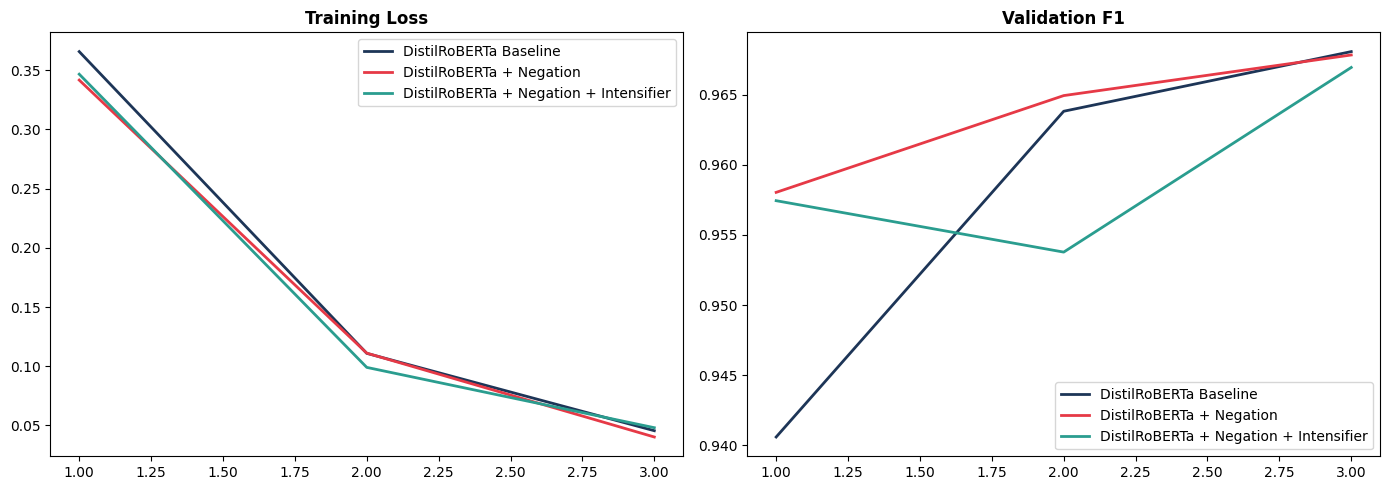

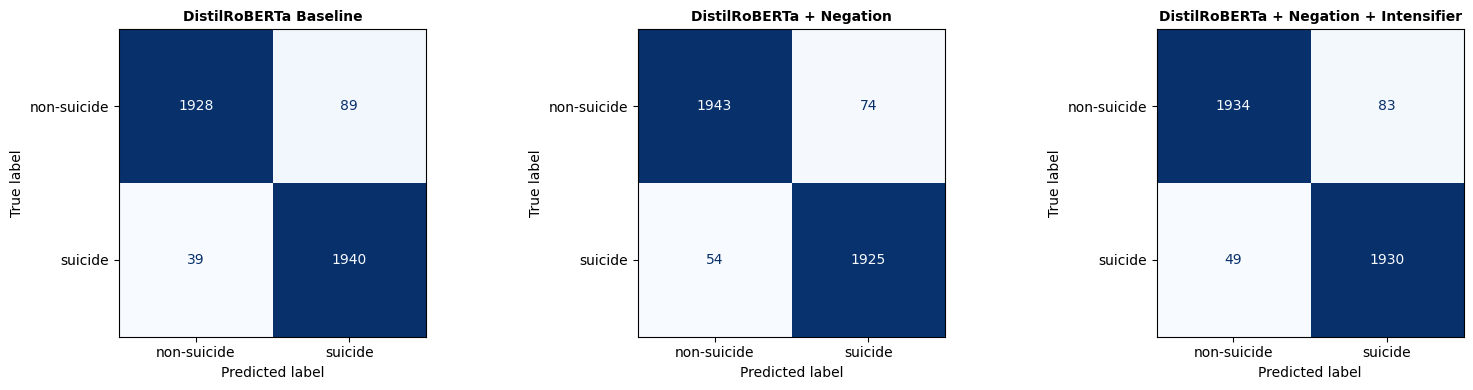

In [11]:
# Compile ablation results
rows = []
for name, m in [(name_base, val_base), (name_neg, val_neg), (name_full, val_full)]:
    rows.append({
        'Experiment': name,
        'Accuracy': round(m['accuracy'], 4),
        'Precision': round(m['precision'], 4),
        'Recall': round(m['recall'], 4),
        'F1': round(m['f1'], 4),
        'ROC-AUC': round(m['roc_auc'], 4)
    })

ablation_df = pd.DataFrame(rows)
print(ablation_df.to_string(index=False))


# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1D3557', '#E63946', '#2A9D8F']

for hist, name, c in zip(
    [hist_base, hist_neg, hist_full],
    [name_base, name_neg, name_full],
    colors
):
    axes[0].plot(hist['epoch'], hist['train_loss'], label=name, color=c, linewidth=2)
    axes[1].plot(hist['epoch'], hist['val_f1'], label=name, color=c, linewidth=2)

for ax, t in zip(axes, ['Training Loss', 'Validation F1']):
    ax.set_title(t, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'distilroberta_model' / 'training_curves.png', bbox_inches='tight')
plt.show()


# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name, m in zip(
    axes,
    [name_base, name_neg, name_full],
    [val_base, val_neg, val_full]
):
    ConfusionMatrixDisplay(
        confusion_matrix(m['labels'], m['preds']),
        display_labels=['non-suicide', 'suicide']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    
    ax.set_title(name, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'distilroberta_model' / 'ablation_cm.png', bbox_inches='tight')
plt.show()

## Early Detection Analysis

This section evaluates how model performance varies when only a limited number of words from each input are available. By truncating text to different lengths, the experiment simulates early-stage detection scenarios.

The results illustrate how effectively the model can identify signals of interest with partial information, highlighting its robustness under constrained input conditions.

window= 50  F1=0.9745  recall=0.9838
window=100  F1=0.9751  recall=0.9889
window=150  F1=0.9751  recall=0.9889


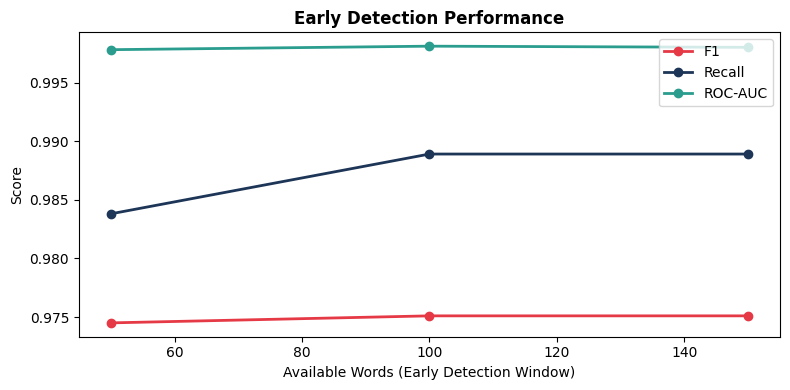

In [12]:
# Helper to truncate text to first n words
def truncate_words(text, n):
    return ' '.join(str(text).split()[:n])


# Evaluate performance across early detection windows
early_results = []

for window in EARLY_DETECTION_WINDOWS:
    test_trunc = test.copy()
    
    # Truncate input text
    test_trunc['text_clean'] = test_trunc['text_clean'].apply(
        lambda x: truncate_words(x, window)
    )
    
    # Prepare dataset and loader
    ds = SuicideDataset(test_trunc, tokenizer, 'text_clean', max_length=MAX_LENGTH)
    ldr = DataLoader(ds, batch_size=BATCH_SIZE * 2, collate_fn=collator)
    
    # Evaluate model
    m = evaluate_epoch(model_base, ldr, nn.CrossEntropyLoss(), DEVICE)
    
    early_results.append({
        'window': window,
        'F1': round(m['f1'], 4),
        'Recall': round(m['recall'], 4),
        'ROC-AUC': round(m['roc_auc'], 4)
    })
    
    print(f'window={window:>3}  F1={m["f1"]:.4f}  recall={m["recall"]:.4f}')


# Convert to DataFrame
early_df = pd.DataFrame(early_results)


# Plot early detection performance
fig, ax = plt.subplots(figsize=(8, 4))

for col, color in [
    ('F1', '#E63946'),
    ('Recall', '#1D3557'),
    ('ROC-AUC', '#2A9D8F')
]:
    ax.plot(
        early_df['window'],
        early_df[col],
        marker='o',
        label=col,
        color=color,
        linewidth=2
    )

ax.set_xlabel('Available Words (Early Detection Window)')
ax.set_ylabel('Score')
ax.set_title('Early Detection Performance', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'distilroberta_model' / 'early_detection.png', bbox_inches='tight')
plt.show()

## Best Model Selection and Final Evaluation

This step selects the best-performing configuration based on validation F1 score and evaluates it on the test dataset. The goal is to obtain an unbiased estimate of the model’s performance on unseen data.

The predictions and evaluation results are saved for reproducibility and further analysis.

In [13]:
# Select best experiment based on validation F1
best_idx = ablation_df['F1'].idxmax()
best_condition = ablation_df.loc[best_idx, 'Experiment']

print(f'Best condition: {best_condition}')

# Map experiment to model and configuration
best_map = {
    name_base: (model_base, 'text_clean', False),
    name_neg:  (model_neg,  'text_neg_tagged', False),
    name_full: (model_full, 'text_neg_tagged', True)
}

bm, bc, bi = best_map[best_condition]

# Prepare test dataset
test_ds = SuicideDataset(
    test,
    tokenizer,
    text_col=bc,
    max_length=MAX_LENGTH,
    use_intensifier=bi
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE * 2,
    collate_fn=collator
)

# Evaluate on test set
test_metrics = evaluate_epoch(
    bm,
    test_loader,
    nn.CrossEntropyLoss(),
    DEVICE
)

# Print classification report
print(classification_report(
    test_metrics['labels'],
    test_metrics['preds'],
    target_names=['non-suicide', 'suicide']
))

# Save predictions and results
with open(DISTILROBERTA_PREDS_PKL, 'wb') as f:
    pickle.dump({
        'ablation': ablation_df,
        'test_preds': test_metrics['preds'],
        'test_labels': test_metrics['labels'],
        'test_probs': test_metrics['probs'],
        'best_condition': best_condition
    }, f)

ablation_df.to_csv(DISTILROBERTA_RESULTS_CSV, index=False)

Best condition: DistilRoBERTa Baseline
              precision    recall  f1-score   support

 non-suicide       0.99      0.96      0.97      1008
     suicide       0.96      0.99      0.98       990

    accuracy                           0.97      1998
   macro avg       0.98      0.98      0.97      1998
weighted avg       0.98      0.97      0.97      1998

